# Topological Band Projector and Chern Marker

This notebook builds a small real-space Qi-Wu-Zhang Chern-insulator Hamiltonian.
A QSVT-style polynomial projector approximates the occupied-band projector, and
a local Chern-marker diagnostic compares it with the exact spectral projector.

The lattice is intentionally small so the notebook remains a fast educational
example rather than a production topological-materials calculation.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_projector_polynomial
from qsvt.rescaling import rescale_hermitian_about_cutoff
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

sigma_x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
sigma_y = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex)
sigma_z = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=complex)
identity_2 = np.eye(2, dtype=complex)

## Real-Space Chern-Insulator Hamiltonian

The model uses two orbitals per site. Open boundaries make it easy to construct
with dense matrices and expose edge effects in the marker.

In [2]:
def site_index(x: int, y: int, orbital: int, length: int) -> int:
    return 2 * (y * length + x) + orbital


def add_block(
    H: np.ndarray, x1: int, y1: int, x2: int, y2: int, block: np.ndarray
) -> None:
    length = int(round(np.sqrt(H.shape[0] / 2)))
    rows = [site_index(x1, y1, orbital, length) for orbital in range(2)]
    cols = [site_index(x2, y2, orbital, length) for orbital in range(2)]
    H[np.ix_(rows, cols)] += block


def qi_wu_zhang_open(length: int, mass: float) -> np.ndarray:
    dim = 2 * length * length
    H = np.zeros((dim, dim), dtype=complex)
    onsite = mass * sigma_z
    hop_x = 0.5 * sigma_z - 0.5j * sigma_x
    hop_y = 0.5 * sigma_z - 0.5j * sigma_y

    for y in range(length):
        for x in range(length):
            add_block(H, x, y, x, y, onsite)
            if x + 1 < length:
                add_block(H, x, y, x + 1, y, hop_x)
                add_block(H, x + 1, y, x, y, hop_x.conj().T)
            if y + 1 < length:
                add_block(H, x, y, x, y + 1, hop_y)
                add_block(H, x, y + 1, x, y, hop_y.conj().T)
    return H


length = 5
mass = -1.0
H = qi_wu_zhang_open(length, mass)
evals, evecs = eigh_hermitian(H)
print("dimension:", H.shape[0])
print("spectral range:", (evals[0], evals[-1]))
print("gap around zero:", np.min(np.abs(evals)))

dimension: 50
spectral range: (np.float64(-2.800243765865765), np.float64(2.8002437658657637))
gap around zero: 0.13742301418061872


## Exact and Polynomial Occupied Projectors

The cutoff is zero. `rescale_hermitian_about_cutoff` maps low-energy states to
positive scaled values, so a projector polynomial selects the occupied band.

In [3]:
occupied = evals < 0.0
exact_projector = evecs[:, occupied] @ evecs[:, occupied].conj().T
scaled = rescale_hermitian_about_cutoff(H, cutoff=0.0, low_energy_positive=True)
scaled_gap = float(np.min(np.abs(np.linalg.eigvalsh(scaled.matrix))))
projector_poly = design_projector_polynomial(
    gamma=min(0.35, 0.8 * scaled_gap),
    degree=13,
    num_points=601,
)
polynomial_projector = apply_polynomial_to_hermitian(scaled.matrix, projector_poly)
projector_error = np.linalg.norm(
    polynomial_projector - exact_projector
) / np.linalg.norm(exact_projector)
print("scaled gap:", scaled_gap)
print("projector relative error:", projector_error)

scaled gap: 0.04907537545686846
projector relative error: 0.14856745583142436


## Local Chern Marker

The marker is evaluated per lattice site by summing the two orbital diagonal
contributions. Boundary sites are visible because this is a finite open system.

In [4]:
def position_operators(length: int) -> tuple[np.ndarray, np.ndarray]:
    coords_x = []
    coords_y = []
    center = 0.5 * (length - 1)
    for y in range(length):
        for x in range(length):
            for _ in range(2):
                coords_x.append(x - center)
                coords_y.append(y - center)
    return np.diag(coords_x), np.diag(coords_y)


def local_chern_marker(projector: np.ndarray, length: int) -> np.ndarray:
    X, Y = position_operators(length)
    Q = np.eye(projector.shape[0], dtype=complex) - projector
    marker_operator = -4.0 * np.pi * np.imag(projector @ X @ Q @ Y @ projector)
    marker = np.zeros((length, length), dtype=float)
    for y in range(length):
        for x in range(length):
            inds = [site_index(x, y, orbital, length) for orbital in range(2)]
            marker[y, x] = float(np.trace(marker_operator[np.ix_(inds, inds)]))
    return marker


exact_marker = local_chern_marker(exact_projector, length)
poly_marker = local_chern_marker(polynomial_projector, length)
marker_error = np.linalg.norm(poly_marker - exact_marker) / np.linalg.norm(exact_marker)
print("marker relative error:", marker_error)
print("bulk exact marker:", exact_marker[1:-1, 1:-1].mean())
print("bulk polynomial marker:", poly_marker[1:-1, 1:-1].mean())

marker relative error: 0.6193314616489696
bulk exact marker: 0.9583268200049554
bulk polynomial marker: 0.4549752848359254


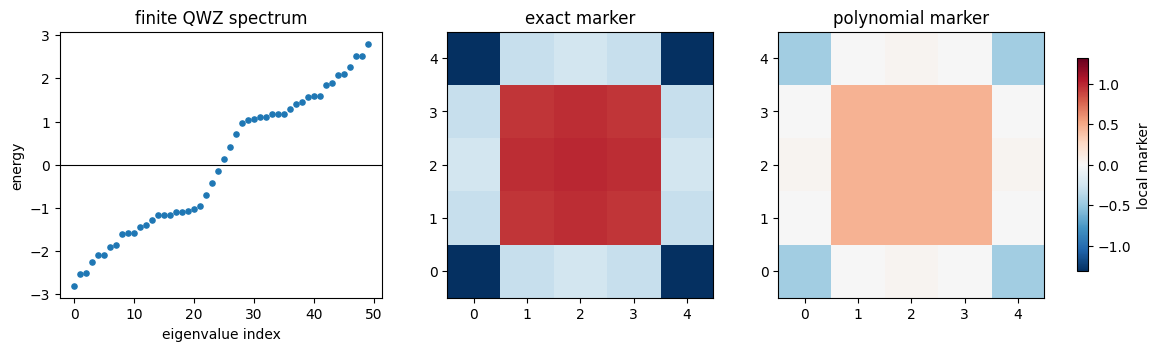

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), constrained_layout=True)
axes[0].scatter(np.arange(len(evals)), evals, s=14)
axes[0].axhline(0.0, color="black", linewidth=0.8)
axes[0].set_xlabel("eigenvalue index")
axes[0].set_ylabel("energy")
axes[0].set_title("finite QWZ spectrum")

vmax = max(np.max(np.abs(exact_marker)), np.max(np.abs(poly_marker)))
image = axes[1].imshow(
    exact_marker, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax
)
axes[1].set_title("exact marker")
axes[2].imshow(poly_marker, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("polynomial marker")
for ax in axes[1:]:
    ax.set_xticks(range(length))
    ax.set_yticks(range(length))
fig.colorbar(image, ax=axes[1:], shrink=0.8, label="local marker")

assert np.isfinite(projector_error)
assert np.isfinite(marker_error)